In [2]:
import pandas as pd

In [3]:
df = pd.read_parquet("air_quality_complete_dataset.parquet")

In [4]:
print(df.shape)
print(df.columns)
df.head()

(50417, 85)
Index(['Samplingpoint', 'Pollutant', 'Start', 'End', 'Value', 'Unit',
       'AggType', 'Validity', 'Verification', 'ResultTime', 'DataCapture',
       'FkObservationLog', 'station_id', 'pollutant_code', 'source_file',
       'Country', 'B-G Namespace', 'Year', 'Air Quality Network',
       'Air Quality Network Name', 'Timezone', 'Air Quality Station EoI Code',
       'Air Quality Station Nat Code', 'Air Quality Station Name',
       'Sampling Point Id', 'Air Pollutant', 'Longitude', 'Latitude',
       'Altitude', 'Altitude Unit', 'Air Quality Station Area',
       'Air Quality Station Type', 'Operational Activity Begin',
       'Operational Activity End', 'Sample Id', 'Inlet Height',
       'Inlet Height Unit', 'Building Distance', 'Building Distance Unit',
       'Kerb Distance', 'Kerb Distance Unit', 'Distance Source',
       'Distance Source Unit', 'Main Emission Sources', 'Heating Emissions',
       'Heating Emissions Unit', 'Mobile', 'Traffic Emissions',
       'Traff

,Samplingpoint,Pollutant,Start,End,Value,Unit,AggType,Validity,Verification,ResultTime,...,Detection Limit,Detection Limit Unit,Documentation,QA Report,Duration,Duration Unit,Cadence,Cadence Unit,Source Data URL,Imported
0,IT/SPO.IT0470A_6001_BETA_2013-12-20_00:00:00,6001,2025-01-30,2025-01-31,29.000000000000000000,ug.m-3,day,1,2,2025-01-31 09:00:00,...,1.0,ug.m-3,Evaluation of uncertainty in progress,in preparation,1440,minute,1440,minute,http://cdr.eionet.europa.eu/it/eu/aqd/d/envanp...,2025-10-01 14:12:21
1,IT/SPO.IT0470A_6001_BETA_2013-12-20_00:00:00,6001,2025-01-31,2025-02-01,27.000000000000000000,ug.m-3,day,1,2,2025-02-03 09:00:00,...,1.0,ug.m-3,Evaluation of uncertainty in progress,in preparation,1440,minute,1440,minute,http://cdr.eionet.europa.eu/it/eu/aqd/d/envanp...,2025-10-01 14:12:21
2,IT/SPO.IT0470A_6001_BETA_2013-12-20_00:00:00,6001,2025-02-01,2025-02-02,5.000000000000000000,ug.m-3,day,1,2,2025-02-03 09:00:00,...,1.0,ug.m-3,Evaluation of uncertainty in progress,in preparation,1440,minute,1440,minute,http://cdr.eionet.europa.eu/it/eu/aqd/d/envanp...,2025-10-01 14:12:21
3,IT/SPO.IT0470A_6001_BETA_2013-12-20_00:00:00,6001,2025-02-02,2025-02-03,10.000000000000000000,ug.m-3,day,1,2,2025-02-03 09:00:00,...,1.0,ug.m-3,Evaluation of uncertainty in progress,in preparation,1440,minute,1440,minute,http://cdr.eionet.europa.eu/it/eu/aqd/d/envanp...,2025-10-01 14:12:21
4,IT/SPO.IT0470A_6001_BETA_2013-12-20_00:00:00,6001,2025-02-03,2025-02-04,26.000000000000000000,ug.m-3,day,1,3,2025-02-04 08:00:00,...,1.0,ug.m-3,Evaluation of uncertainty in progress,in preparation,1440,minute,1440,minute,http://cdr.eionet.europa.eu/it/eu/aqd/d/envanp...,2025-10-01 14:12:21


In [5]:
cols_to_keep = [
    "station_id",
    "Pollutant",
    "Start",
    "Value",
    "Unit",
    "Country",
    "Municipality",
    "Longitude",
    "Latitude",
    "Altitude",
    "Validity",
    "Verification"
]

df = df[cols_to_keep]

In [6]:
# target
df = df.dropna(subset=["Value"])

# tempo
df["Start"] = pd.to_datetime(df["Start"])

# rename per chiarezza
df = df.rename(columns={"Value": "y"})

In [7]:
df["month"] = df["Start"].dt.month
df["day_of_week"] = df["Start"].dt.dayofweek

In [8]:
df["station_idx"] = df["station_id"].astype("category").cat.codes
df = df[(df["Validity"] == 1) & (df["Verification"] >= 2)]
df = df.copy()

In [9]:
print(df["station_id"].nunique())
print(df.groupby("station_id").size().describe())

119
count    119.000000
mean     265.092437
std       84.384511
min        5.000000
25%      275.000000
50%      299.000000
75%      314.000000
max      332.000000
dtype: float64


In [10]:
counts = df.groupby("station_id").size()
valid_stations = counts[counts >= 30].index
df = df[df["station_id"].isin(valid_stations)]

In [11]:
df.groupby("station_id").size().describe()

count    116.000000
mean     271.431034
std       75.471760
min       69.000000
25%      278.500000
50%      300.000000
75%      314.250000
max      332.000000
dtype: float64

In [21]:
# variables for the model
df["Start"] = pd.to_datetime(df["Start"])
df = df.rename(columns={"Value": "y"})
df["station_idx"] = df["station_id"].astype("category").cat.codes
df["month"] = df["Start"].dt.month
df["day_of_week"] = df["Start"].dt.dayofweek

df = df.drop(columns=['Validity', 'Verification'])

In [24]:
df['y'] = pd.to_numeric(df['y'], errors='coerce')

In [31]:
df = df[df['y'] > 0]

In [22]:
df

,station_id,Pollutant,Start,y,Unit,Country,Municipality,Longitude,Latitude,Altitude,month,day_of_week,station_idx
0,IT0470A,6001,2025-01-30,29.000000000000000000,ug.m-3,Italy,Piazza Rebaudengo 23,7.69534,45.10407,233.0,1,3,0
1,IT0470A,6001,2025-01-31,27.000000000000000000,ug.m-3,Italy,Piazza Rebaudengo 23,7.69534,45.10407,233.0,1,4,0
2,IT0470A,6001,2025-02-01,5.000000000000000000,ug.m-3,Italy,Piazza Rebaudengo 23,7.69534,45.10407,233.0,2,5,0
3,IT0470A,6001,2025-02-02,10.000000000000000000,ug.m-3,Italy,Piazza Rebaudengo 23,7.69534,45.10407,233.0,2,6,0
4,IT0470A,6001,2025-02-03,26.000000000000000000,ug.m-3,Italy,Piazza Rebaudengo 23,7.69534,45.10407,233.0,2,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
50093,IT2318A,6001,2025-12-26,3.599999000000000000,ug.m-3,Italy,"Trapani, c/o Diga Rubino",12.71802,37.88248,186.0,12,4,115
50094,IT2318A,6001,2025-12-27,4.599999000000000000,ug.m-3,Italy,"Trapani, c/o Diga Rubino",12.71802,37.88248,186.0,12,5,115
50095,IT2318A,6001,2025-12-28,4.500000000000000000,ug.m-3,Italy,"Trapani, c/o Diga Rubino",12.71802,37.88248,186.0,12,6,115
50096,IT2318A,6001,2025-12-29,4.099999000000000000,ug.m-3,Italy,"Trapani, c/o Diga Rubino",12.71802,37.88248,186.0,12,0,115


# EDA
istogramma di y
istogramma di log(y)
media/mediana/deviazione standard
numero osservazioni per stazione
variabilità within-station e between-station

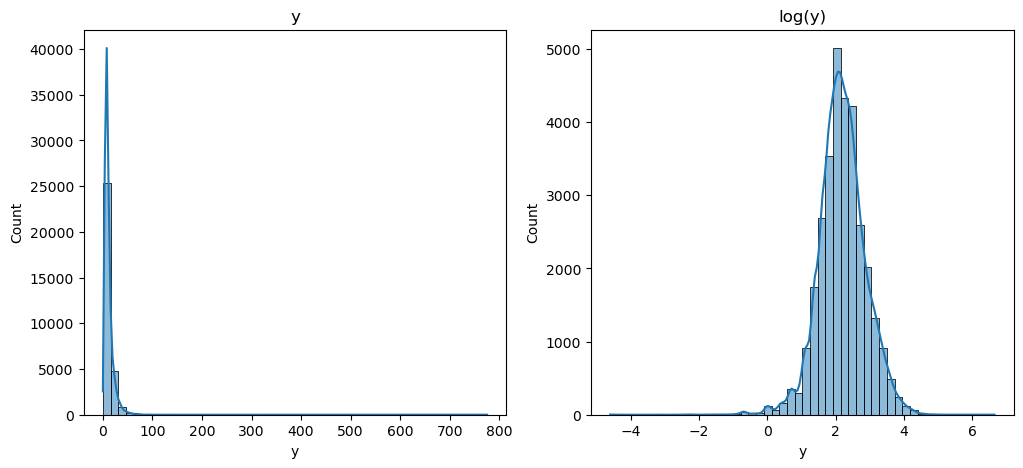

In [32]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(12,5))

sns.histplot(df['y'], bins=50, kde=True, ax=axes[0])
axes[0].set_title("y")

sns.histplot(np.log(df['y']), bins=50, kde=True, ax=axes[1])
axes[1].set_title("log(y)")

plt.show()

The distribution of PM2.5 concentrations is highly right-skewed, with a long upper tail. A logarithmic transformation is therefore applied to stabilize variance and approximate normality. The transformed variable exhibits an approximately symmetric distribution, justifying the use of a Gaussian likelihood within a Bayesian framework.

In [40]:
import numpy as np

# y
print("Y stats:")
print(df['y'].describe())
print("Skewness:", df['y'].skew())

# log(y)
df.loc[:, 'log_y'] = np.log(df['y'])
print("\nlog(Y) stats:")
print(df['log_y'].describe())
print("Skewness:", df['log_y'].skew())

Y stats:
count    31349.000000
mean        11.332326
std         10.203518
min          0.010000
25%          6.000000
50%          9.000000
75%         13.399997
max        775.599800
Name: y, dtype: float64
Skewness: 17.060319591535382

log(Y) stats:
count    31349.000000
mean         2.192835
std          0.686157
min         -4.605170
25%          1.791759
50%          2.197225
75%          2.595254
max          6.653637
Name: log_y, dtype: float64
Skewness: -0.2855314599340311


The raw PM2.5 concentrations exhibit strong right skewness (skewness = 17.06), with extreme outliers. After log-transformation, the distribution becomes approximately symmetric (skewness = -0.28), supporting the use of a Gaussian likelihood.

In [34]:
obs_per_station = df.groupby('station_id').size()

print(obs_per_station.describe())

count    116.000000
mean     270.250000
std       76.169134
min       69.000000
25%      278.500000
50%      299.500000
75%      314.000000
max      332.000000
dtype: float64


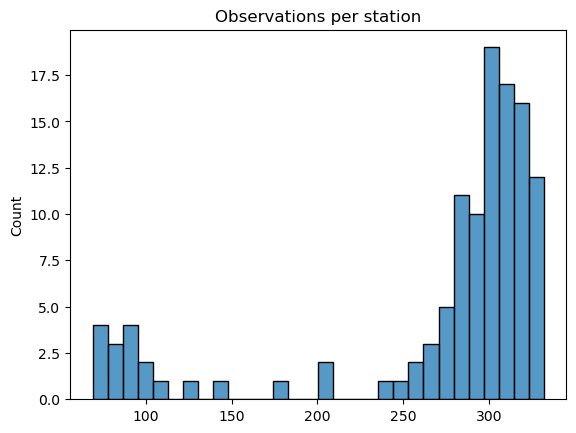

In [35]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(obs_per_station, bins=30)
plt.title("Observations per station")
plt.show()

In [36]:
within_var = df.groupby('station_id')['log_y'].var()
within_std = df.groupby('station_id')['log_y'].std()

print(within_var.describe())

count    116.000000
mean       0.396475
std        0.176356
min        0.113457
25%        0.267165
50%        0.381373
75%        0.485196
max        1.063553
Name: log_y, dtype: float64


In [37]:
station_means = df.groupby('station_id')['log_y'].mean()

between_var = station_means.var()
between_std = station_means.std()

print("Between-station variance:", between_var)
print("Between-station std:", between_std)

Between-station variance: 0.08515585471689807
Between-station std: 0.2918147609647224


In [38]:
print("Mean within-station variance:", within_var.mean())
print("Between-station variance:", between_var)

Mean within-station variance: 0.39647483188882526
Between-station variance: 0.08515585471689807


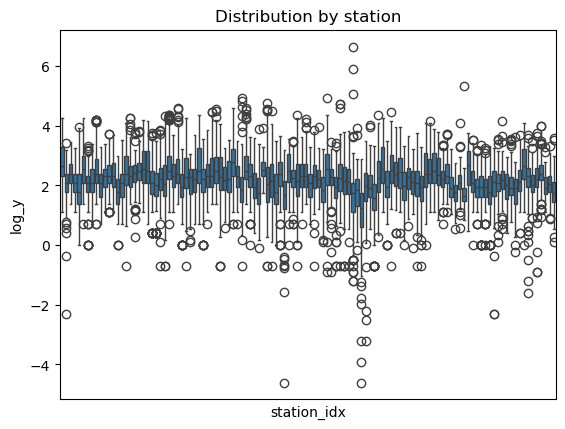

In [39]:
sns.boxplot(x='station_idx', y='log_y', data=df)
plt.title("Distribution by station")
plt.xticks([])  # troppe stazioni
plt.show()

The analysis reveals substantial within-station variability in PM2.5 concentrations, alongside non-negligible differences in average pollution levels across monitoring stations. While within-station variance dominates, the presence of systematic between-station variation supports the inclusion of station-specific random effects in a hierarchical Bayesian framework.

In [42]:
df.to_csv("pm25_bayes.csv", index=False)